In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import platform

# OS별 한글 폰트 자동 설정
if platform.system() == 'Darwin':        # Mac
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':      # Windows
    plt.rc('font', family='Malgun Gothic')
else:                                     # Linux / Colab
    plt.rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False  # 한글 폰트 쓸 때 마이너스(-) 기호 깨지는 것도 같이 방지

# 데이터 로드

In [2]:
# 데이터 로드
# df_2021 = pd.read_excel("YP2021_w01.xlsx", engine="calamine") # 1차
# df_2022 = pd.read_excel("YP2021_w02.xlsx", engine="calamine") # 2차
# df_2023 = pd.read_excel("YP2021_w03.xlsx", engine="calamine") # 3차
df_2024 = pd.read_excel("YP2021_w04.xlsx", engine="calamine") # 4차 -> 가장 최근 데이터 

df_2024.head()

,sampid,hid,gender,w01,w02,w03,w04,BIRTHy,BIRTHm,ED_region1,...,y04f515,y04f516a,y04f516b,y04f516c,y04f517,y04f518,y04f519a,y04f519b,y04f519c,y04f520
0,100001,900001,2,1,1,1,1,2000,9,11,...,2.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN
1,100002,900002,2,1,1,1,1,2002,5,11,...,1.0,1.0,2.0,8.0,120.0,2.0,NaN,NaN,NaN,NaN
2,100003,900003,2,1,1,1,1,1998,5,11,...,1.0,8.0,NaN,NaN,80.0,2.0,NaN,NaN,NaN,NaN
3,100004,900003,2,1,1,1,1,1996,4,11,...,2.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN
4,100005,900004,1,1,1,1,1,1998,7,11,...,1.0,1.0,2.0,8.0,100.0,2.0,NaN,NaN,NaN,NaN


In [3]:
# 원본 데이터
df_2024.info()
df_2024.shape
df = df_2024
# dtypes: float64(1507), int64(28), object(14)
# Columns: 1549, RangeIndex: 12213

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12213 entries, 0 to 12212
Columns: 1549 entries, sampid to y04f520
dtypes: float64(1507), int64(28), object(14)
memory usage: 144.3+ MB


# 데이터 전처리

## 필요 컬럼 추출 및 데이터 재구조화

In [4]:
# 필요 컬럼으로 데이터셋 재구조화
# 필요한 컬럼 매핑 딕셔너리 정의 (원본 컬럼명 : 변경할 변수명)
column_mapping = {
    'sampid': 'user_id',                 # 패널 고유 ID
    'gender': 'gender',                  # 성별 (1: 남 / 2: 여)
    'w04age': 'age',                     # 만 나이
    'w04edu': 'edu_level',               # 최종학력 상태
    'w04region': 'region_code',          # 거주 지역 시도 코드
    'y04f517': 'parent_support_wage',    # 부모님으로부터의 경제적 지원 금액
    'w04ecoact': 'eco_status_total',     # 경제활동상태 통합 변수 (Target 기준점)
    'y04c001': 'is_working_for_pay',     # 수입목적 근로 여부
    'y04c004': 'employment_status',      # 종사상 지위 (임금/비임금 등 일자리 형태)
    'y04c211a': 'weekly_work_hours',     # 주당 평소 근로시간 
    'y04c714': 'gov_job_program',        # 정부 취업지원 프로그램 참여 여부 
    'y04c715': 'gov_vocational_train',   # 정부 직업훈련 참여 여부
    'y04c106x': 'current_job_code',      # 현재 일자리의 4자리 직업코드 (KSCO)
    'y04c113': 'active_job_hunting',     # 적극적 구직활동 여부 
    'y04d010_1': 'num_applications',     # 원서접수 및 면접 횟수 
    'y04d011_1': 'desired_wage',         # 희망 임금 
    'y04d013_1': 'desired_job',          # 희망 직무/직종 코드 (문자열 포함)
    'y04e001': 'is_preparing_exam',      # 시험 준비 여부
    'y04e003_1': 'exam_type',            # 준비 시험 종류 코드 (문자열 포함)
    'y04b001': 'job_retention_status'    # 과거 일자리 유지 여부
}

In [5]:
# 원본 데이터에서 필요한 컬럼들만 슬라이싱 추출
available_columns = [col for col in column_mapping.keys() if col in df.columns]
df_sliced = df[available_columns].copy()
df_sliced
# 12213 rows × 20 columns
# 만약 오타를 내서 column_mapping에 존재하지도 않는 임의의 컬럼명을 적었더라도, 이 코드가 원본에 없는 컬럼은 자동으로 걸러내 주기 때문에 파이썬이 중간에 멈추거나 에러가 생기는 것을 막아준다.

,sampid,gender,w04age,w04edu,w04region,y04f517,w04ecoact,y04c001,y04c004,y04c211a,y04c714,y04c715,y04c106x,y04c113,y04d010_1,y04d011_1,y04d013_1,y04e001,y04e003_1,y04b001
0,100001,2,24,2.0,1,NaN,1.0,1.0,NaN,NaN,1.0,2.0,2647,2.0,NaN,NaN,NaN,2.0,NaN,3.0
1,100002,2,22,2.0,1,120.0,3.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,3.0
2,100003,2,26,4.0,1,80.0,3.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,3.0
3,100004,2,28,4.0,1,NaN,1.0,1.0,NaN,NaN,NaN,NaN,2466,NaN,NaN,NaN,NaN,2.0,NaN,1.0
4,100005,1,26,2.0,1,100.0,3.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12208,112210,2,27,4.0,1,NaN,1.0,1.0,NaN,NaN,NaN,NaN,2534,NaN,NaN,NaN,NaN,2.0,NaN,1.0
12209,112211,1,23,2.0,1,NaN,1.0,1.0,NaN,NaN,NaN,NaN,5212,NaN,NaN,NaN,NaN,2.0,NaN,1.0
12210,112212,1,23,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12211,112213,2,26,4.0,7,70.0,3.0,2.0,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN,1.0,6.0,3.0


In [6]:
# 실제로 변수명을 보기 쉽게 변경 -> column_mapping: 매핑 해놓은 컬럼
df_sliced = df_sliced.rename(columns=column_mapping) 
df_sliced

,user_id,gender,age,edu_level,region_code,parent_support_wage,eco_status_total,is_working_for_pay,employment_status,weekly_work_hours,gov_job_program,gov_vocational_train,current_job_code,active_job_hunting,num_applications,desired_wage,desired_job,is_preparing_exam,exam_type,job_retention_status
0,100001,2,24,2.0,1,NaN,1.0,1.0,NaN,NaN,1.0,2.0,2647,2.0,NaN,NaN,NaN,2.0,NaN,3.0
1,100002,2,22,2.0,1,120.0,3.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,3.0
2,100003,2,26,4.0,1,80.0,3.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,3.0
3,100004,2,28,4.0,1,NaN,1.0,1.0,NaN,NaN,NaN,NaN,2466,NaN,NaN,NaN,NaN,2.0,NaN,1.0
4,100005,1,26,2.0,1,100.0,3.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12208,112210,2,27,4.0,1,NaN,1.0,1.0,NaN,NaN,NaN,NaN,2534,NaN,NaN,NaN,NaN,2.0,NaN,1.0
12209,112211,1,23,2.0,1,NaN,1.0,1.0,NaN,NaN,NaN,NaN,5212,NaN,NaN,NaN,NaN,2.0,NaN,1.0
12210,112212,1,23,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12211,112213,2,26,4.0,7,70.0,3.0,2.0,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN,1.0,6.0,3.0


## 데이터 정제

In [7]:
# 데이터 정제
# 4차년도 실제 설문 참여자만 필터링 
# (조사에 참여하지 않은 패널은 경제활동 통합변수가 결측치이거나 특정 코드로 채워져 있음)
# 변수 내에 정상 응답(1:취업, 2:실업(구직의사o), 3:비경활(구직의사x))인 데이터만 남김
df_clean = df_sliced[df_sliced['eco_status_total'].isin([1, 2, 3])].copy()
df_clean # 9665 rows × 20 columns

,user_id,gender,age,edu_level,region_code,parent_support_wage,eco_status_total,is_working_for_pay,employment_status,weekly_work_hours,gov_job_program,gov_vocational_train,current_job_code,active_job_hunting,num_applications,desired_wage,desired_job,is_preparing_exam,exam_type,job_retention_status
0,100001,2,24,2.0,1,NaN,1.0,1.0,NaN,NaN,1.0,2.0,2647,2.0,NaN,NaN,NaN,2.0,NaN,3.0
1,100002,2,22,2.0,1,120.0,3.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,3.0
2,100003,2,26,4.0,1,80.0,3.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,3.0
3,100004,2,28,4.0,1,NaN,1.0,1.0,NaN,NaN,NaN,NaN,2466,NaN,NaN,NaN,NaN,2.0,NaN,1.0
4,100005,1,26,2.0,1,100.0,3.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12207,112209,2,25,4.0,1,NaN,3.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,3.0
12208,112210,2,27,4.0,1,NaN,1.0,1.0,NaN,NaN,NaN,NaN,2534,NaN,NaN,NaN,NaN,2.0,NaN,1.0
12209,112211,1,23,2.0,1,NaN,1.0,1.0,NaN,NaN,NaN,NaN,5212,NaN,NaN,NaN,NaN,2.0,NaN,1.0
12211,112213,2,26,4.0,7,70.0,3.0,2.0,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN,1.0,6.0,3.0


In [8]:
# 설문 무응답 고유 코드(이상치/무효값)를 머신러닝이 인식할 수 있는 결측치로 변환
# 청년패널 코드북상 9090908(응답거절), 9090909(모름) 및 기타 무효 처리용 큰 수들을 제거
invalid_codes = [9090908, 9090909, 99999, 999999, 9999999]
df_clean = df_clean.replace(invalid_codes, np.nan)
df_clean 

,user_id,gender,age,edu_level,region_code,parent_support_wage,eco_status_total,is_working_for_pay,employment_status,weekly_work_hours,gov_job_program,gov_vocational_train,current_job_code,active_job_hunting,num_applications,desired_wage,desired_job,is_preparing_exam,exam_type,job_retention_status
0,100001,2,24,2.0,1,NaN,1.0,1.0,NaN,NaN,1.0,2.0,2647,2.0,NaN,NaN,NaN,2.0,NaN,3.0
1,100002,2,22,2.0,1,120.0,3.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,3.0
2,100003,2,26,4.0,1,80.0,3.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,3.0
3,100004,2,28,4.0,1,NaN,1.0,1.0,NaN,NaN,NaN,NaN,2466,NaN,NaN,NaN,NaN,2.0,NaN,1.0
4,100005,1,26,2.0,1,100.0,3.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12207,112209,2,25,4.0,1,NaN,3.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,3.0
12208,112210,2,27,4.0,1,NaN,1.0,1.0,NaN,NaN,NaN,NaN,2534,NaN,NaN,NaN,NaN,2.0,NaN,1.0
12209,112211,1,23,2.0,1,NaN,1.0,1.0,NaN,NaN,NaN,NaN,5212,NaN,NaN,NaN,NaN,2.0,NaN,1.0
12211,112213,2,26,4.0,7,70.0,3.0,2.0,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN,1.0,6.0,3.0


## 시각화 전 전처리

In [9]:
# 필요 없는 컬럼 드랍
drop_cols = ['parent_support_wage', 'job_retention_status', 'is_working_for_pay', 'current_job_code', 'desired_job', 'exam_type', 'desired_wage', 'active_job_hunting']
# 부모지원금, 과거 일자리유지 여부, 수입목적 근로여부, 현재직업코드, 준비하고 있는 시험, 희망직종, 희망임금, 구직활동여부

df_selected = df_clean.drop(columns=drop_cols, errors='ignore')
df_selected # 9665 rows × 12 columns

,user_id,gender,age,edu_level,region_code,eco_status_total,employment_status,weekly_work_hours,gov_job_program,gov_vocational_train,num_applications,is_preparing_exam
0,100001,2,24,2.0,1,1.0,NaN,NaN,1.0,2.0,NaN,2.0
1,100002,2,22,2.0,1,3.0,2.0,NaN,NaN,NaN,NaN,2.0
2,100003,2,26,4.0,1,3.0,2.0,NaN,NaN,NaN,NaN,2.0
3,100004,2,28,4.0,1,1.0,NaN,NaN,NaN,NaN,NaN,2.0
4,100005,1,26,2.0,1,3.0,2.0,NaN,NaN,NaN,NaN,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
12207,112209,2,25,4.0,1,3.0,2.0,NaN,NaN,NaN,NaN,2.0
12208,112210,2,27,4.0,1,1.0,NaN,NaN,NaN,NaN,NaN,2.0
12209,112211,1,23,2.0,1,1.0,NaN,NaN,NaN,NaN,NaN,2.0
12211,112213,2,26,4.0,7,3.0,2.0,NaN,2.0,2.0,NaN,1.0


In [10]:
# 결측치 확인
df_selected.isnull().sum()

user_id                    0
gender                     0
age                        0
edu_level                  0
region_code                0
eco_status_total           0
employment_status       6134
weekly_work_hours       9568
gov_job_program         8460
gov_vocational_train    8460
num_applications        9590
is_preparing_exam          0
dtype: int64

In [11]:
# 0으로 채우는 항목: 해당 활동을 안 했거나(횟수 0), 점수가 없는 경우(0점/없음)
cols_to_zero = [
    'num_applications', 'weekly_work_hours'
]
df_selected[cols_to_zero] = df_selected[cols_to_zero].fillna(0)

# 정부 프로그램 결측치는 '미참여(2)'로 채우기 -> 무응답은 미참여로 간주
cols_to_two = ['gov_job_program', 'gov_vocational_train']
df_selected[cols_to_two] = df_selected[cols_to_two].fillna(2)

In [12]:
# -1로 채우는 항목 (범주형)
# # 일자리 형태 컬럼 -> '해당 없음' 또는 '미취업' 상태를 별도의 코드로 분류 -> 선택지에 없는 -1로 해당없음을 표시
cols_to_category = [
    'employment_status'
]
df_selected[cols_to_category] = df_selected[cols_to_category].fillna(-1)

In [13]:
df_selected.isnull().sum()

user_id                 0
gender                  0
age                     0
edu_level               0
region_code             0
eco_status_total        0
employment_status       0
weekly_work_hours       0
gov_job_program         0
gov_vocational_train    0
num_applications        0
is_preparing_exam       0
dtype: int64

In [14]:
# 진짜 직장 취업 성공 여부 (Y값 = 0 또는 1) 생성
# 조건: 경제활동상태가 취업자(1)이면 1 아니면 미취업자(0)
df_selected['target_employed'] = np.where(
    (df_selected['eco_status_total'] == 1), 1, 0)

# 결과 확인
print(df_selected['target_employed'].value_counts())

target_employed
1    6134
0    3531
Name: count, dtype: int64


In [15]:
# 각 컬럼별 고윳값의 개수 확인
print(df_selected.nunique())

user_id                 9665
gender                     2
age                       10
edu_level                  5
region_code               17
eco_status_total           3
employment_status          3
weekly_work_hours          9
gov_job_program            2
gov_vocational_train       2
num_applications           6
is_preparing_exam          2
target_employed            2
dtype: int64


In [16]:
# 모델 학습에 사용할 x 데이터셋 준비
# 타겟 변수 생성에 직접적으로 사용되었거나 정답을 유추할 수 있는 변수들을 제외
drop_for_vis= [
    'eco_status_total', 
    'employment_status',
    'weekly_work_hours'
]

In [17]:
# 전체 데이터프레임의 인덱스를 'user_id'로 설정
df_indexed = df_selected.set_index('user_id')

In [18]:
# 동일한 인덱스를 가진 상태에서 X와 y를 안전하게 분리
X = df_indexed.drop(columns=['target_employed'] + drop_for_vis)
y = df_indexed['target_employed']

In [19]:
print("X 데이터 모양:", X.shape)
print("y 데이터 모양:", y.shape)
print("X의 인덱스 예시:", X.index[:3].tolist())
print("y의 인덱스 예시:", y.index[:3].tolist())

X 데이터 모양: (9665, 8)
y 데이터 모양: (9665,)
X의 인덱스 예시: [100001, 100002, 100003]
y의 인덱스 예시: [100001, 100002, 100003]


In [20]:
# 결측값 확인
print("--- X 결측치 수 ---")
print(X.isnull().sum())
print("\n--- y 결측치 수 ---")
print(y.isnull().sum())
print("\n--- 원본 데이터 결측치 수 ---")
print(df_selected.isnull().sum())

--- X 결측치 수 ---
gender                  0
age                     0
edu_level               0
region_code             0
gov_job_program         0
gov_vocational_train    0
num_applications        0
is_preparing_exam       0
dtype: int64

--- y 결측치 수 ---
0

--- 원본 데이터 결측치 수 ---
user_id                 0
gender                  0
age                     0
edu_level               0
region_code             0
eco_status_total        0
employment_status       0
weekly_work_hours       0
gov_job_program         0
gov_vocational_train    0
num_applications        0
is_preparing_exam       0
target_employed         0
dtype: int64


## 영향도 시각화 - 카이제곱

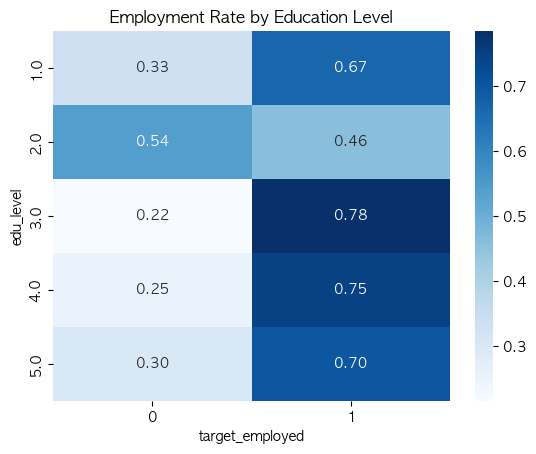

target_employed     0     1
edu_level                  
1.0              0.33  0.67
2.0              0.54  0.46
3.0              0.22  0.78
4.0              0.25  0.75
5.0              0.30  0.70


In [21]:
# 학력(edu_level)과 취업여부(target_employed)의 비율 교차표 만들기 
# 1 = 고졸미만
# 2 = 고졸
# 3 = 전문대졸
# 4 = 대졸
# 5 = 석사학위 이상
ct = pd.crosstab(df_selected['edu_level'], df_selected['target_employed'], normalize='index')

# 교차표를 기반으로 한 히트맵 시각화
sns.heatmap(ct, annot=True, cmap='Blues', fmt='.2f')
plt.title('Employment Rate by Education Level')
plt.show()
print(ct.round(2))

/var/folders/1j/tv0k1dlj4zxfg8tvnx6wwcch0000gn/T/ipykernel_8564/1629281030.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=influence_df.values, y=influence_df.index, palette='Blues_r')


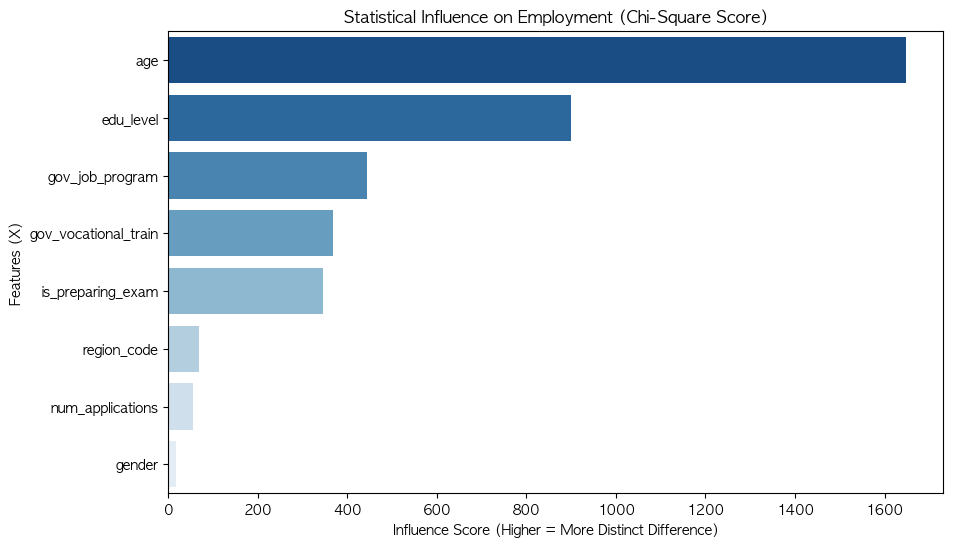

통계적으로 영향도가 가장 높은 상위 5개 변수: ['age', 'edu_level', 'gov_job_program', 'gov_vocational_train', 'is_preparing_exam']


In [22]:
from scipy.stats import chi2_contingency

# 카이제곱용 변수 별도 선언 (원핫인코딩 전 상태)
X_chi = df_indexed.drop(columns=['target_employed'] + drop_for_vis)
y_chi = df_indexed['target_employed']

chi2_scores = {}

for col in X_chi.columns:
    crosstab = pd.crosstab(X_chi[col], y_chi)
    chi2, p, dof, ex = chi2_contingency(crosstab)
    chi2_scores[col] = chi2

influence_df = pd.Series(chi2_scores).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=influence_df.values, y=influence_df.index, palette='Blues_r')
plt.title('Statistical Influence on Employment (Chi-Square Score)')
plt.xlabel('Influence Score (Higher = More Distinct Difference)')
plt.ylabel('Features (X)')
plt.show()

top_5_features = influence_df.head(5).index.tolist()
print("통계적으로 영향도가 가장 높은 상위 5개 변수:", top_5_features)

## 최종 학력에 따라 취업 시장에서 살아남는 비율(취업률)이 다르다

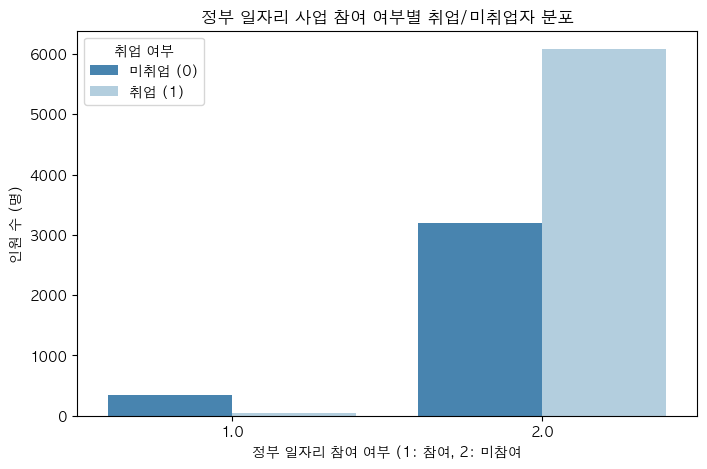

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# gov_job_program 별 target_employed 비율 계산
plt.figure(figsize=(8, 5))
sns.countplot(data=df_selected, x='gov_job_program', hue='target_employed', palette='Blues_r')

plt.title('정부 일자리 사업 참여 여부별 취업/미취업자 분포')
plt.xlabel('정부 일자리 참여 여부 (1: 참여, 2: 미참여')
plt.ylabel('인원 수 (명)')
plt.legend(title='취업 여부', labels=['미취업 (0)', '취업 (1)'])
plt.show()
# 참여 모수가 적어 통계적 해석에 한계가 있다.

/var/folders/1j/tv0k1dlj4zxfg8tvnx6wwcch0000gn/T/ipykernel_8564/1809666152.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_selected, x='target_employed', palette='Blues_r')


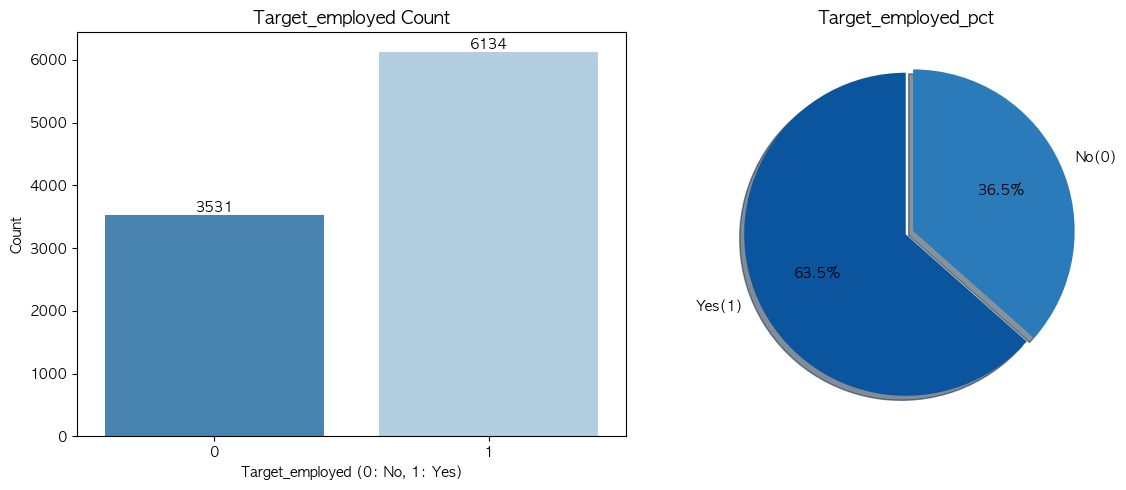

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. 타겟 변수(target_employed) 분포 확인 (클래스 불균형 체크)
plt.figure(figsize=(12, 5))

# 1-1 카운트 플롯
plt.subplot(1, 2, 1)
ax = sns.countplot(data=df_selected, x='target_employed', palette='Blues_r')
plt.title('Target_employed Count', fontsize=13, weight='bold')
plt.xlabel('Target_employed (0: No, 1: Yes)')
plt.ylabel('Count')

# 바 상단에 실제 수치 표시(명)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)

# 1-2 파이 차트 (비율 확인)
plt.subplot(1, 2, 2)
target_counts = df_selected['target_employed'].value_counts()
plt.pie(target_counts, labels=['Yes(1)', 'No(0)'], autopct='%1.1f%%', 
        startangle=90, colors=sns.color_palette('Blues_r'), explode=[0, 0.05], shadow=True)
plt.title('Target_employed_pct', fontsize=13, weight='bold')

plt.tight_layout()
plt.show()

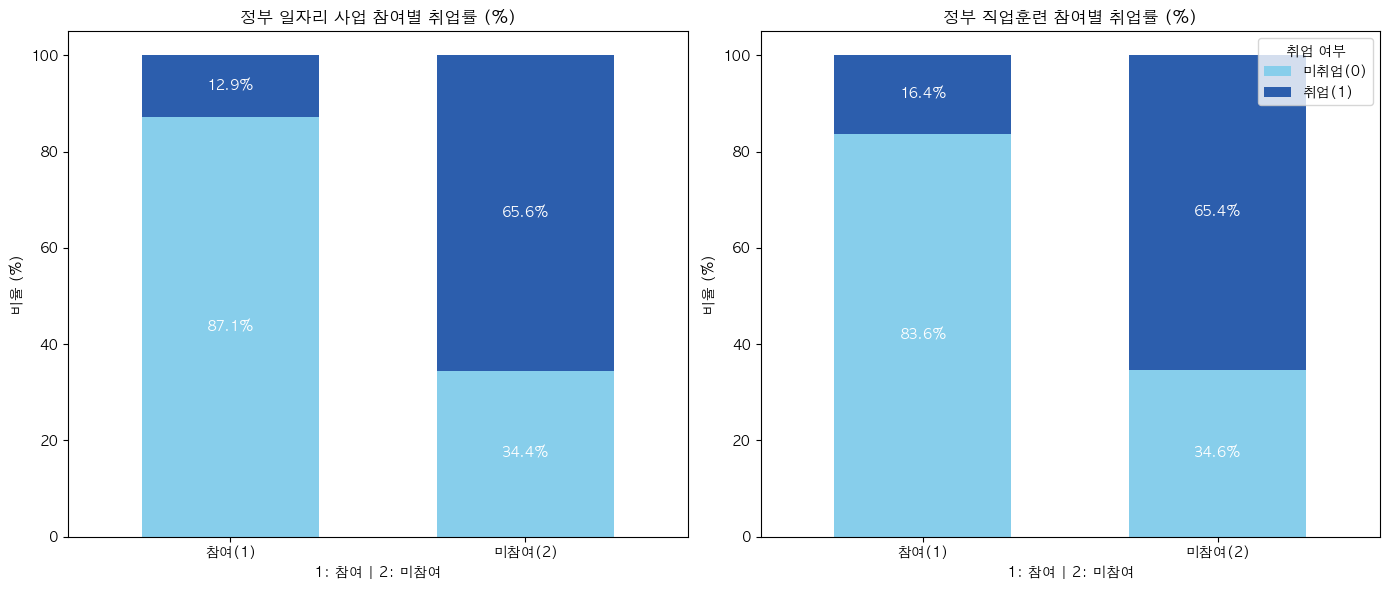

In [25]:
# 일자리 사업 vs 직업훈련 진짜 취업률 비교 (100% 누적 바 차트)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. 정부 일자리 사업 비율 교차표 생성 및 시각화
ct_job = pd.crosstab(df_selected['gov_job_program'], df_selected['target_employed'], normalize='index') * 100
ct_job.plot(kind='bar', stacked=True, color=['skyblue', '#2C5EAD'], ax=axes[0], width=0.6)
axes[0].set_title('정부 일자리 사업 참여별 취업률 (%)', fontsize=12, weight='bold')
axes[0].set_xlabel('1: 참여 | 2: 미참여')
axes[0].set_ylabel('비율 (%)')
axes[0].set_xticklabels(['참여(1)', '미참여(2)'], rotation=0)
axes[0].get_legend().remove()

# 각 바 안에 % 수치 기입
for p in axes[0].patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        axes[0].annotate(f'{height:.1f}%', (x + width/2, y + height/2), ha='center', va='center', color='white', weight='bold')

# 2. 정부 직업훈련 비율 교차표 생성 및 시각화
ct_train = pd.crosstab(df_selected['gov_vocational_train'], df_selected['target_employed'], normalize='index') * 100
ct_train.plot(kind='bar', stacked=True, color=['skyblue', '#2C5EAD'], ax=axes[1], width=0.6)
axes[1].set_title('정부 직업훈련 참여별 취업률 (%)', fontsize=12, weight='bold')
axes[1].set_xlabel('1: 참여 | 2: 미참여')
axes[1].set_ylabel('비율 (%)')
axes[1].set_xticklabels(['참여(1)', '미참여(2)'], rotation=0)
axes[1].legend(title='취업 여부', labels=['미취업(0)', '취업(1)'], loc='upper right')

# 각 바 안에 % 수치 기입
for p in axes[1].patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        axes[1].annotate(f'{height:.1f}%', (x + width/2, y + height/2), ha='center', va='center', color='white', weight='bold')

plt.tight_layout()
plt.savefig('05_policy_efficiency_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 모델링

## 모델링 전 전처리 - 데이터 누수
## 처음 전처리: 기초 정제 과정 -> 지금: 모델의 학습 효율과 데이터 누수를 방지하기 위한 최적화 과정
## 모델 - XG Boost 선정

In [26]:
# [데이터 누수 및 불필요 변수 정리]

# 1. 힌트 제공 변수(데이터 누수) 및 의미 없는 변수 제거 리스트
drop_cols = [
    'weekly_work_hours',   # 데이터 누수 위험
    'employment_status',   # 종사상 지위 (누수 위험)
    'eco_status_total',    # 타겟 생성 기준이라 반드시 제거
]

# 2. 지정한 변수들을 안전하게 드롭 -> user_id는 드랍하지 않고 인덱스로
df_modeling = df_selected.set_index('user_id').drop(columns=[col for col in drop_cols if col in df_selected.columns])

# [범주형 변수 원핫 인코딩]

# 3. 원핫 인코딩을 적용할 범주형 변수 지정
categorical_cols = [
    'gender',
    'edu_level',
    'region_code'
]

# 4. 판다스를 이용해 원핫 인코딩 적용 (True/False 대신 1과 0으로 채우도록 dtype 지정)
df_modeling = pd.get_dummies(df_modeling, columns=categorical_cols, drop_first=True, dtype=int) # drop_first=True: 다중공선성 방지 

print("▶ 전처리 및 인코딩 완료 후 최종 데이터 구조:", df_modeling.shape)

▶ 전처리 및 인코딩 완료 후 최종 데이터 구조: (9665, 27)


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np

# X, y 정의 - df_modeling 기준으로 통일
X = df_modeling.drop(columns=['target_employed'])
y = df_modeling['target_employed']

# 학습/테스트 분리
# stratify=y를 써서 학습용과 테스트용 데이터 모두 원본과 똑같은 취업/미취업 비율을 유지하도록 안전장치 걸기

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"학습 데이터 모양: {X_train.shape}, 테스트 데이터 모양: {X_test.shape}")

# 모델 정의
# LR: class_weight='balanced'를 줘서 소수 집단(미취업자)을 맞췄을 때 가산점을 주도록 설정
# RF: 마찬가지로 balanced 가산점 주기
# XGBoost: scale_pos_weight로 미취업과 취업의 비율을 계산해 불균형을 방지

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', n_estimators=100, random_state=42
    ),
    'XGBoost': xgb.XGBClassifier(
        scale_pos_weight=(y==0).sum()/(y==1).sum(),
        n_estimators=100, random_state=42, eval_metric='logloss'
    )
}
# 결과를 저장할 빈 딕셔너리 초기화
results = {}

# 딕셔너리에 담긴 모델들을 하나씩 꺼내어 반복문 돌리기
for name, model in models.items():
    
    # [학습] 80%의 학습 데이터로 모델 훈련
    model.fit(X_train, y_train)
    
    # [예측] 20%의 시험 데이터로 "이 사람 취업할까?" 예측값(0 또는 1) 추출
    y_pred = model.predict(X_test)
    
    # [확률 계산] "취업할 확률이 몇 %인가?" 0~1 사이의 연속된 확률 점수 추출
    y_prob = model.predict_proba(X_test)[:, 1]

    # [AUC 점수] 모델의 전반적인 판별력 점수(0.5 ~ 1.0 사이, 1에 가까울수록 완벽) 계산
    auc = roc_auc_score(y_test, y_prob)

    # 교차 검증을 통해 모델이 어떤 데이터가 들어와도 일관되고 안정적인 성능(일반화 성능)을 내는지 더블 체크
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')

    # 결과 저장(시각화용)
    results[name] = {
        'model': model,
        'AUC': auc,
        'CV_AUC_mean': cv_scores.mean(),
        'CV_AUC_std': cv_scores.std()
    }

    # 모델별 성적표 출력
    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred, target_names=['미취업(0)', '취업(1)']))
    print(f"Test AUC: {auc:.3f} / CV AUC (Mean): {cv_scores.mean():.3f}")

# 불균형 데이터에서는 무조건 다 '취업(1)'이라고만 찍어도 정확도가 높게 나오는 착시 현상이 생긴다.
# 모델이 0과 1을 얼마나 잘 판별하는지 보는 AUC 점수와, 실제 미취업자를 놓치지 않고 찾아내는 재현율(Recall)을 중점적으로 보기 위해 셋팅(AUC, F1-score)    

학습 데이터 모양: (7732, 26), 테스트 데이터 모양: (1933, 26)

===== Logistic Regression =====
              precision    recall  f1-score   support

      미취업(0)       0.61      0.72      0.66       706
       취업(1)       0.82      0.74      0.78      1227

    accuracy                           0.73      1933
   macro avg       0.72      0.73      0.72      1933
weighted avg       0.75      0.73      0.74      1933

Test AUC: 0.788 / CV AUC (Mean): 0.799

===== Random Forest =====
              precision    recall  f1-score   support

      미취업(0)       0.63      0.68      0.65       706
       취업(1)       0.80      0.77      0.79      1227

    accuracy                           0.73      1933
   macro avg       0.72      0.72      0.72      1933
weighted avg       0.74      0.73      0.74      1933

Test AUC: 0.775 / CV AUC (Mean): 0.764

===== XGBoost =====
              precision    recall  f1-score   support

      미취업(0)       0.64      0.69      0.66       706
       취업(1)       0.81      0.7

In [49]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

print("▶ XGBoost 하이퍼파라미터 튜닝을 시작합니다... (약 1~2분 소요)")

# 1. 탐색할 XGBoost 파라미터 조합 설정
param_grid = {
    'max_depth': [3, 5, 7],              # 트리 깊이 (너무 깊으면 과적합)
    'learning_rate': [0.01, 0.05, 0.1],   # 학습률 (가중치 업데이트 속도)
    'n_estimators': [100, 200]           # 만들 나무의 개수
}

# 2. 그리드 서치 정의 (XGBoost 맞춤형 scale_pos_weight 유지)
grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(
        scale_pos_weight=(y==0).sum()/(y==1).sum(), # 클래스 불균형 해결
        random_state=42, 
        eval_metric='logloss'
    ),
    param_grid=param_grid,  # 5fold 교차검증
    cv=5, 
    scoring='roc_auc',
    n_jobs=-1
)

# 3. 최적 조합 학습
grid_search.fit(X_train, y_train)

# 4. 결과 확인
y_test_prob_tuned = grid_search.best_estimator_.predict_proba(X_test)[:, 1]
test_auc_tuned = roc_auc_score(y_test, y_test_prob_tuned)
print(f"튜닝 후 Test AUC: {test_auc_tuned:.3f} / CV AUC(mean): {grid_search.best_score_:.3f}")
print(f"최적 하이퍼파라미터: max_depth={grid_search.best_params_['max_depth']}, "
      f"learning_rate={grid_search.best_params_['learning_rate']}, "
      f"n_estimators={grid_search.best_params_['n_estimators']}")

# 5. 최적의 모델을 변수에 저장
best_xgb_model = grid_search.best_estimator_

▶ XGBoost 하이퍼파라미터 튜닝을 시작합니다... (약 1~2분 소요)
튜닝 후 Test AUC: 0.795 / CV AUC(mean): 0.804
최적 하이퍼파라미터: max_depth=5, learning_rate=0.05, n_estimators=100


# Feature Importance 시각화

In [50]:
# X, y 재정의 (df_modeling 이미 전처리 완료 상태)
X = df_modeling.drop(columns=['target_employed'])
y = df_modeling['target_employed']

# 튜닝 결과 적용 최종 모델 학습
final_model = xgb.XGBClassifier(
    **grid_search.best_params_,
    scale_pos_weight=(y==0).sum()/(y==1).sum(),
    random_state=42,
    eval_metric='logloss'
)
final_model.fit(X, y)

# 변수 중요도 데이터프레임
feature_importances = pd.DataFrame({
    'feature': X.columns,
    'importance': final_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("🏆 상위 10개 중요 변수:")
print(feature_importances.head(10))

🏆 상위 10개 중요 변수:
                 feature  importance
6          edu_level_2.0    0.174779
0                    age    0.149691
4      is_preparing_exam    0.136624
1        gov_job_program    0.119986
2   gov_vocational_train    0.048859
3       num_applications    0.044035
23        region_code_15    0.038775
14         region_code_6    0.032095
12         region_code_4    0.025654
24        region_code_16    0.024438


In [51]:
# edu_level 관련 변수만 따로 추출해서 비교
edu_features = feature_importances[feature_importances['feature'].str.contains('edu_level')]
print(edu_features)
top_edu = edu_features.sort_values('importance', ascending=False).iloc[0]
print(f"학력 변수 중 {top_edu['feature']}의 중요도가 {top_edu['importance']:.3f}로 가장 높다")

         feature  importance
6  edu_level_2.0    0.174779
7  edu_level_3.0    0.024144
9  edu_level_5.0    0.017598
8  edu_level_4.0    0.015732
학력 변수 중 edu_level_2.0의 중요도가 0.175로 가장 높다


/var/folders/1j/tv0k1dlj4zxfg8tvnx6wwcch0000gn/T/ipykernel_8564/953736336.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


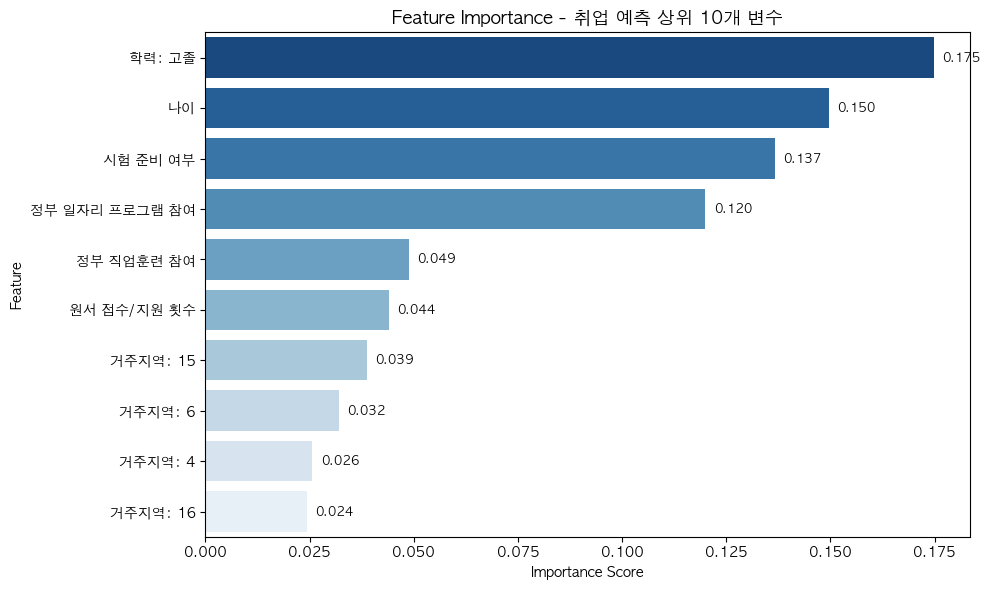

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 상위 10개만 추출
top10 = feature_importances.head(10).copy()

# 변수명 한글로 매핑 (가독성)
label_map = {
    'age': '나이',
    'edu_level_2.0': '학력: 고졸',
    'is_preparing_exam': '시험 준비 여부',
    'gov_job_program': '정부 일자리 프로그램 참여',
    'gov_vocational_train': '정부 직업훈련 참여',
    'region_code_15': '거주지역: 15',
    'region_code_6': '거주지역: 6',
    'region_code_4': '거주지역: 4',
    'region_code_16': '거주지역: 16',
    'num_applications': '원서 접수/지원 횟수'
    
}

top10['label'] = top10['feature'].map(label_map).fillna(top10['feature'])

plt.figure(figsize=(10, 6))
sns.barplot(
    x='importance',
    y='label',
    data=top10,
    palette='Blues_r'
)

plt.title('Feature Importance - 취업 예측 상위 10개 변수', fontsize=13, weight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

# 각 바에 수치 표시
for i, (val, _) in enumerate(zip(top10['importance'], top10['label'])):
    plt.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/1j/tv0k1dlj4zxfg8tvnx6wwcch0000gn/T/ipykernel_8564/3675575824.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='label', data=top10, palette='Blues_r', ax=axes[0])
/var/folders/1j/tv0k1dlj4zxfg8tvnx6wwcch0000gn/T/ipykernel_8564/3675575824.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='label', data=edu_features, palette='Blues_r', ax=axes[1])


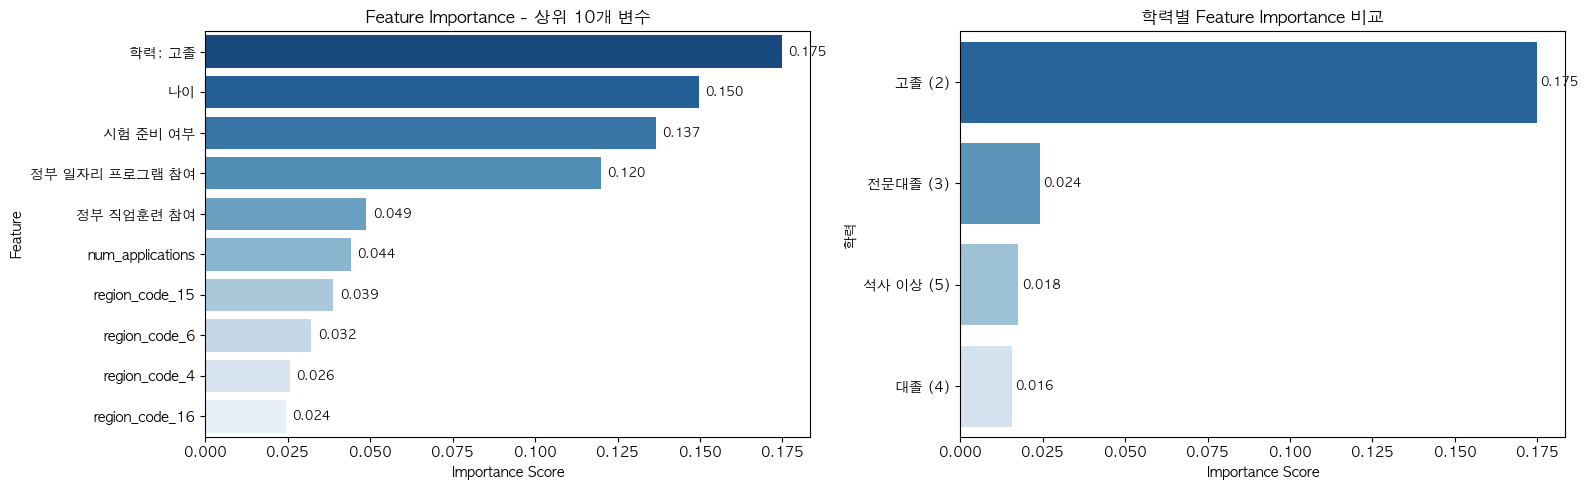

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# edu_level 전체 추출
edu_features = feature_importances[
    feature_importances['feature'].str.contains('edu_level')
].copy()

# 한글 라벨 매핑
edu_label_map = {
    'edu_level_2.0': '고졸 (2)',
    'edu_level_3.0': '전문대졸 (3)',
    'edu_level_4.0': '대졸 (4)',
    'edu_level_5.0': '석사 이상 (5)',
}
edu_features['label'] = edu_features['feature'].map(edu_label_map)

# 중요도 내림차순 정렬
edu_features = edu_features.sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── 왼쪽: 전체 Feature Importance 상위 10개 ──
top10 = feature_importances.head(10).copy()
label_map = {
    'age': '나이',
    'edu_level_2.0': '학력: 고졸',
    'is_preparing_exam': '시험 준비 여부',
    'gov_job_program': '정부 일자리 프로그램 참여',
    'gov_vocational_train': '정부 직업훈련 참여',
    'edu_level_3.0': '학력: 전문대졸',
    'edu_level_4.0': '학력: 대졸',
    'region_code_11': '거주지역: 11',
    'gender_2': '성별: 여성'
}
top10['label'] = top10['feature'].map(label_map).fillna(top10['feature'])

sns.barplot(x='importance', y='label', data=top10, palette='Blues_r', ax=axes[0])
axes[0].set_title('Feature Importance - 상위 10개 변수', fontsize=12, weight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].set_ylabel('Feature')

for i, val in enumerate(top10['importance']):
    axes[0].text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)

# ── 오른쪽: 학력별 중요도 비교 ──
sns.barplot(x='importance', y='label', data=edu_features, palette='Blues_r', ax=axes[1])
axes[1].set_title('학력별 Feature Importance 비교', fontsize=12, weight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].set_ylabel('학력')

for i, val in enumerate(edu_features['importance']):
    axes[1].text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance_with_edu.png', dpi=300, bbox_inches='tight')
plt.show()

# 미취업 청년 데이터만 넣고 모델 돌리기
## 미취업 청년의 취업 확률 예측
## 파생변수(취업 확률) 생성

In [54]:
# 미취업 청년 식별
# 전체 데이터(df_modeling)에서 미취업자만 필터링
df_unemployed = df_modeling[df_modeling['target_employed'] == 0].copy()

# 모델이 예측할 X 데이터셋 생성 (타겟 변수 제거)
X_unemployed = df_unemployed.drop(columns=['target_employed'])

print(f"▶ 분석할 미취업 청년 수: {len(X_unemployed)}명")

▶ 분석할 미취업 청년 수: 3531명


In [55]:
# '취업(1) 될 확률' 예측
unemployed_probs = final_model.predict_proba(X_unemployed)[:, 1]

# 파생 변수 생성: 예측 확률 데이터프레임에 추가
df_unemployed['predicted_prob'] = unemployed_probs

# 확률이 낮은 순서대로 정렬하여 고위험군(취업 확률 낮은 청년) 확인
df_target = df_unemployed.sort_values(by='predicted_prob', ascending=True)

# # 하위 10명 데이터 확인
# print(df_target[['predicted_prob']].head(10))

## 전체 취업청년 vs 미취업청년 특징 비교

취업청년 vs 미취업청년 평균 비교
     미취업(0)   취업(1)  평균 차이
age  24.793  27.119  2.326


/var/folders/1j/tv0k1dlj4zxfg8tvnx6wwcch0000gn/T/ipykernel_8564/2488898008.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


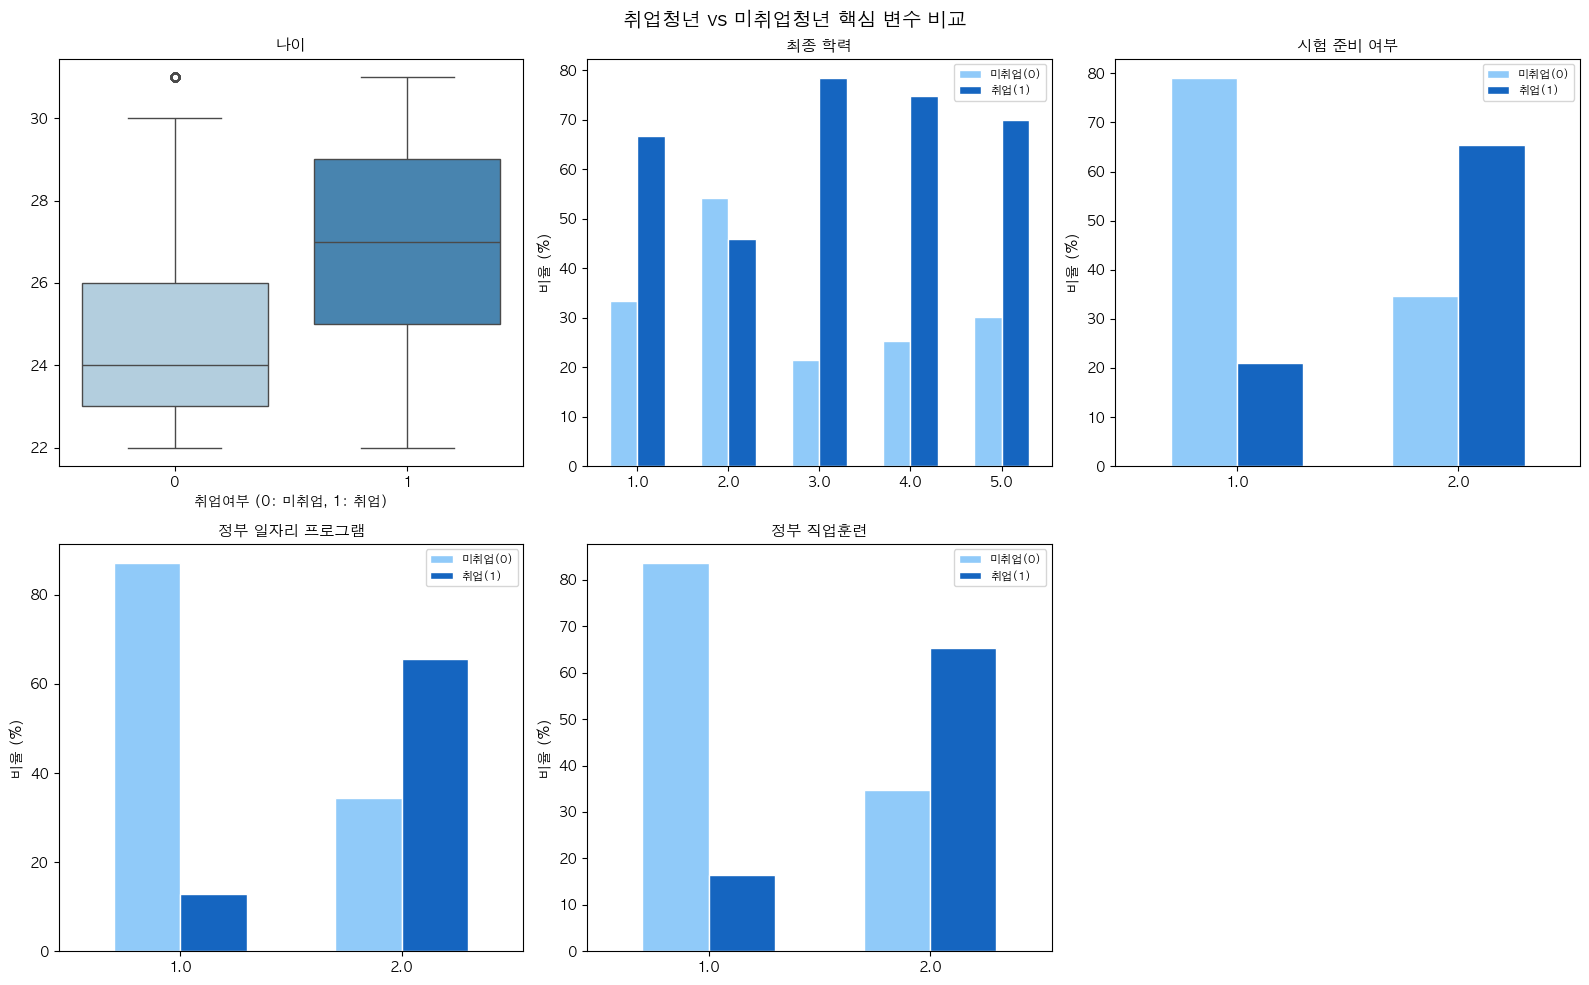

In [56]:
# 전체 취업청년 vs 미취업청년 특징 비교

# 원본 변수 기준으로 비교 (원핫인코딩 전 df_selected)
# Feature Importance 상위 핵심 변수만 비교
continuous_cols = ['age']  # 연속형 - 박스플롯
categorical_cols_compare = [               # 범주형 - 막대그래프
    'edu_level',
    'is_preparing_exam',
    'gov_job_program',
    'gov_vocational_train'
]

# 취업(1) vs 미취업(0) 그룹별 평균 비교
compare_df = df_selected.groupby('target_employed')[continuous_cols].mean().T
compare_df.columns = ['미취업(0)', '취업(1)']
compare_df['평균 차이'] = compare_df['취업(1)'] - compare_df['미취업(0)']

print("취업청년 vs 미취업청년 평균 비교")
print(compare_df.round(3))

# 시각화
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

col_labels = {
    'age': '나이',
    'edu_level': '최종 학력',
    'is_preparing_exam': '시험 준비 여부',
    'gov_job_program': '정부 일자리 프로그램',
    'gov_vocational_train': '정부 직업훈련'
}

# 연속형 - 박스플롯
for i, col in enumerate(continuous_cols):
    sns.boxplot(
        data=df_selected,
        x='target_employed',
        y=col,
        palette='Blues',
        ax=axes[i]
    )
    axes[i].set_title(col_labels[col], fontsize=11, weight='bold')
    axes[i].set_xlabel('취업여부 (0: 미취업, 1: 취업)')
    axes[i].set_ylabel('')

# 범주형 - 그룹 막대그래프
for j, col in enumerate(categorical_cols_compare):
    ct = pd.crosstab(df_selected[col], df_selected['target_employed'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[j + len(continuous_cols)], 
            color=['#90CAF9', '#1565C0'], edgecolor='white', width=0.6)
    axes[j + len(continuous_cols)].set_title(col_labels[col], fontsize=11, weight='bold')
    axes[j + len(continuous_cols)].set_xlabel('')
    axes[j + len(continuous_cols)].set_ylabel('비율 (%)')
    axes[j + len(continuous_cols)].tick_params(axis='x', rotation=0)
    axes[j + len(continuous_cols)].legend(['미취업(0)', '취업(1)'], fontsize=8)

# 안 쓴 axes 삭제
used = len(continuous_cols) + len(categorical_cols_compare)  # = 5
for ax in axes[used:]:
    fig.delaxes(ax)
    
plt.suptitle('취업청년 vs 미취업청년 핵심 변수 비교', fontsize=14, weight='bold')
plt.tight_layout()
plt.savefig('comparison_employed_vs_unemployed.png', dpi=300, bbox_inches='tight')
plt.show()

## 취업 확률 하위 20% 고위험군 식별
## 하위 20%의 학력 분포 시각화

In [57]:
# df_selected 기반으로 고위험군 학력 분포 추출
# user_id(index) 기준으로 자동 정렬 매칭
edu_map = {1.0: '고졸미만', 2.0: '고졸', 3.0: '전문대졸', 4.0: '대졸', 5.0: '석사이상'}

df_selected_indexed = df_selected.set_index('user_id')
df_selected_unemployed = df_selected_indexed[df_selected_indexed['target_employed'] == 0].copy()

threshold_20 = df_target['predicted_prob'].quantile(0.20)

# df_unemployed도 user_id를 index로 갖고 있으니, 대입 시 pandas가 알아서 같은 user_id끼리 매칭해줌
df_selected_unemployed['predicted_prob'] = df_unemployed['predicted_prob']

df_selected_high_risk = df_selected_unemployed[
    df_selected_unemployed['predicted_prob'] <= threshold_20
].reset_index()  # CSV로 저장할 거니까 user_id를 다시 일반 컬럼으로 복원

In [58]:
# 1. 최종 엑셀/CSV 파일에서도 보기 싫은 무의미한 컬럼들 정의
final_drop_cols = [
    'employment_status',  # 미취업자라 어차피 다 -1 또는 결측치
    'weekly_work_hours',  # 전부 0인 컬럼
    'target_employed',    # 전부 0인 컬럼
    'num_applications'    # 전체 중 96%가 0인 컬럼
]

# 2. 최종 저장 직전에 안전하게 드롭
df_selected_high_risk_clean = df_selected_high_risk.drop(columns=final_drop_cols, errors='ignore')

# 3. 정제된 데이터셋으로 다시 저장하기
df_selected_high_risk_clean.to_csv('high_risk_youth.csv', index=False)

고위험군 학력 분포:
edu_level
고졸      497
대졸      194
전문대졸     33
석사이상     11
Name: count, dtype: int64


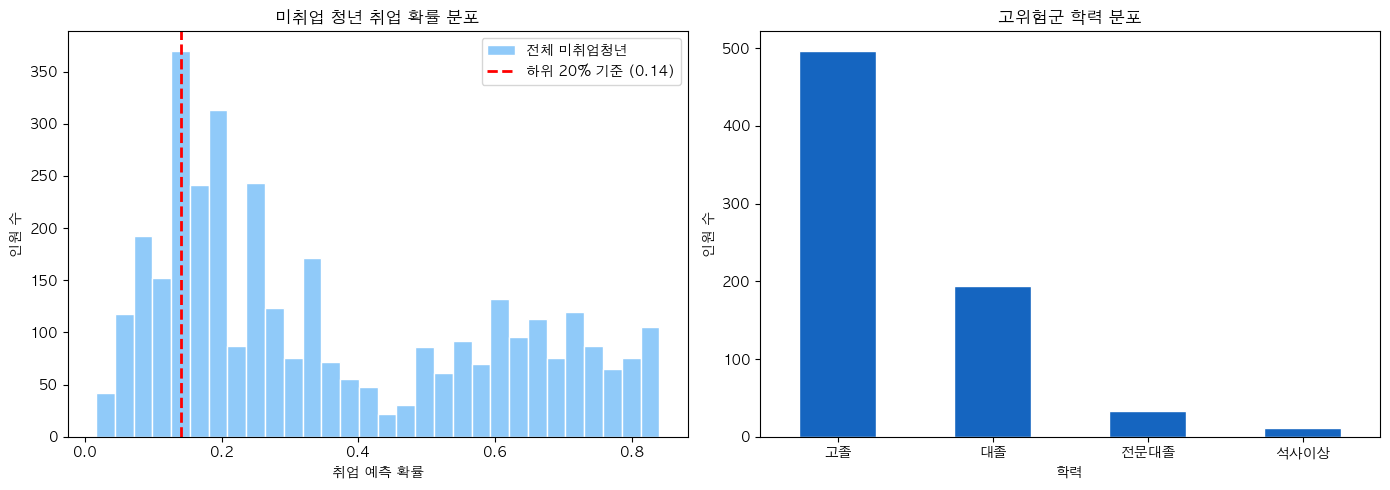


✅ 고위험군 735명 식별 완료


In [59]:
edu_dist = df_selected_high_risk_clean['edu_level'].map(edu_map).value_counts()
print("고위험군 학력 분포:")
print(edu_dist)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(df_target['predicted_prob'], bins=30, color='#90CAF9',
             edgecolor='white', label='전체 미취업청년')
axes[0].axvline(threshold_20, color='red', linestyle='--',
                linewidth=2, label=f'하위 20% 기준 ({threshold_20:.2f})')
axes[0].set_title('미취업 청년 취업 확률 분포', fontsize=12, weight='bold')
axes[0].set_xlabel('취업 예측 확률')
axes[0].set_ylabel('인원 수')
axes[0].legend()

# 학력 분포
edu_dist.plot(kind='bar', color='#1565C0', ax=axes[1], edgecolor='white')
axes[1].set_title('고위험군 학력 분포', fontsize=12, weight='bold')
axes[1].set_xlabel('학력')
axes[1].set_ylabel('인원 수')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('high_risk_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ 고위험군 {len(df_selected_high_risk_clean)}명 식별 완료")

## 하위 20% 특성 전체 시각화

고위험군 전체 인원: 735명

[최종 학력] 인원 / 비율
  고졸: 497명 (67.6%)
  대졸: 194명 (26.4%)
  전문대졸: 33명 (4.5%)
  석사이상: 11명 (1.5%)

[시험 준비 여부] 인원 / 비율
  1.0: 185명 (25.2%)
  2.0: 550명 (74.8%)

[정부 일자리 프로그램] 인원 / 비율
  1.0: 316명 (43.0%)
  2.0: 419명 (57.0%)

[정부 직업훈련] 인원 / 비율
  1.0: 275명 (37.4%)
  2.0: 460명 (62.6%)



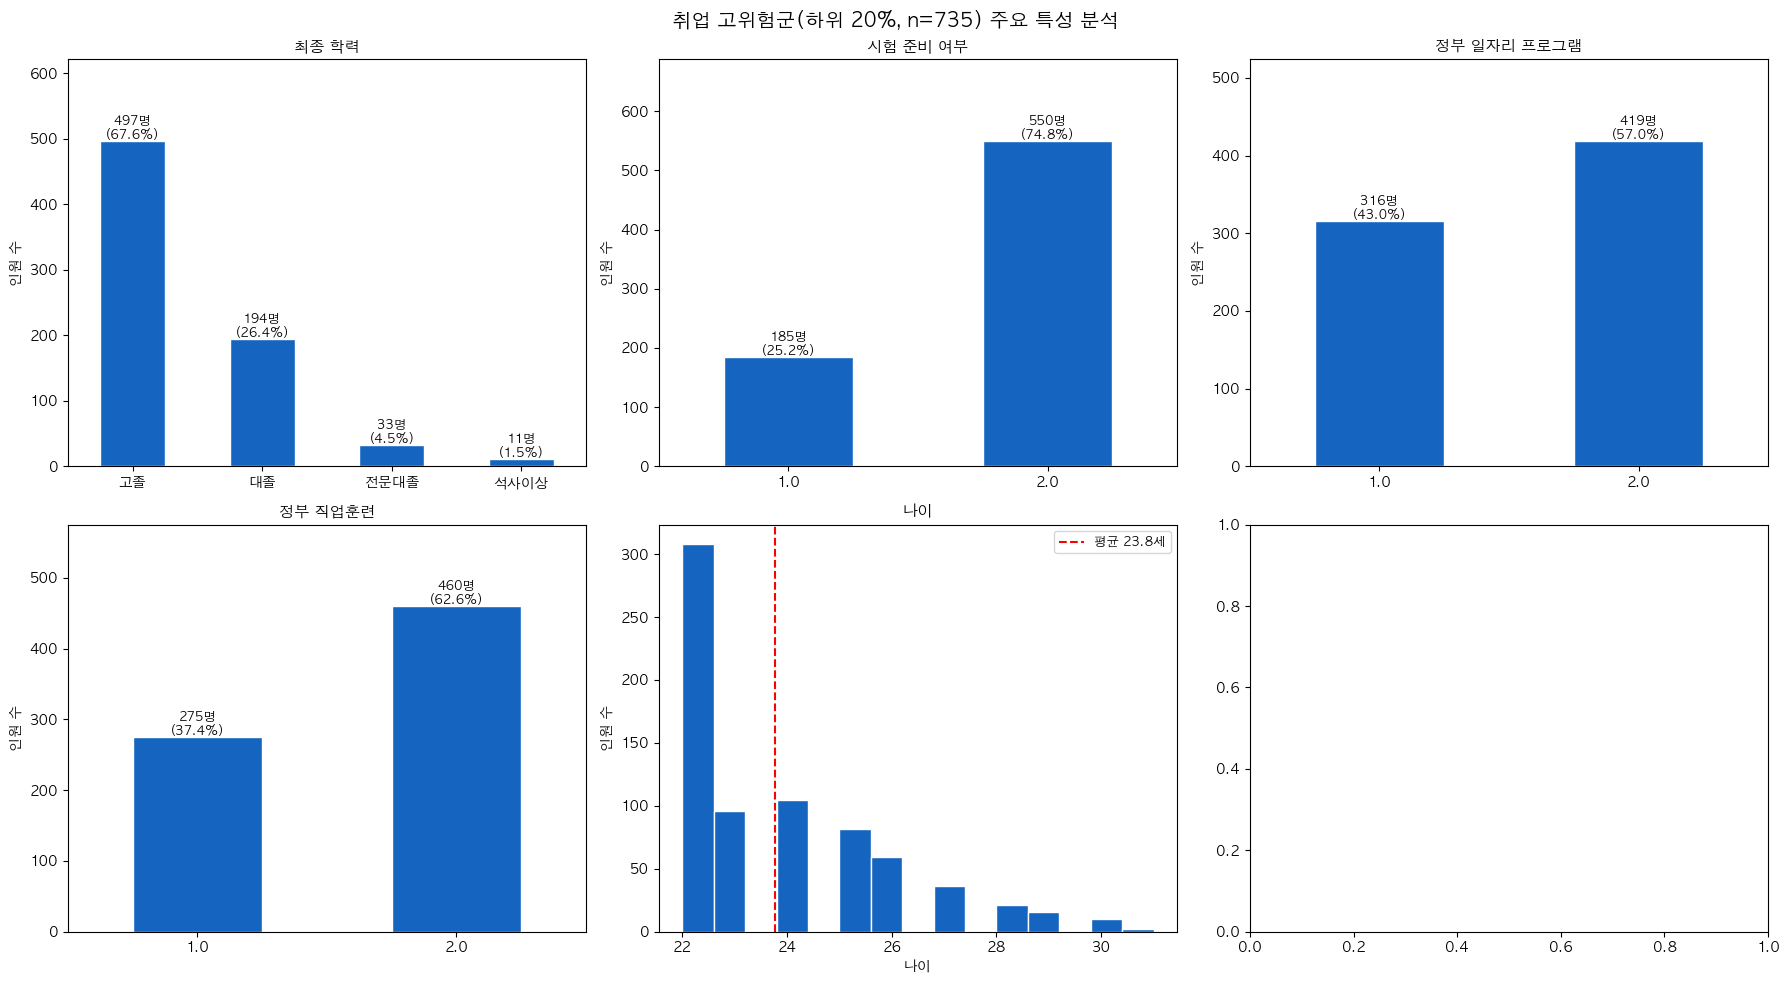

In [60]:
# 고위험군 주요 특성 전체 시각화 (인원 수 + 비율(%) 함께 표기)
compare_cols_risk = [
    'edu_level',
    'is_preparing_exam', 
    'gov_job_program',
    'gov_vocational_train',
    'age'
]

col_labels = {
    'edu_level': '최종 학력',
    'is_preparing_exam': '시험 준비 여부',
    'gov_job_program': '정부 일자리 프로그램',
    'gov_vocational_train': '정부 직업훈련',
    'age': '나이'
}

edu_map = {1.0: '고졸미만', 2.0: '고졸', 3.0: '전문대졸', 4.0: '대졸', 5.0: '석사이상'}

# 전체 인원을 하드코딩하지 않고 실제 데이터에서 계산 (문서상 775명 -> 실제는 759명이었던 것처럼
# 어딘가에서 값이 바뀌어도 텍스트와 숫자가 어긋나지 않도록)
n_total = len(df_selected_high_risk_clean)
print(f"고위험군 전체 인원: {n_total}명\n")

def add_pct_labels(ax, counts, total):
    """막대 위에 '인원수 (비율%)' 라벨을 추가"""
    for patch, val in zip(ax.patches, counts):
        pct = val / total * 100
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            patch.get_height(),
            f'{int(val)}명\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=9
        )

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(compare_cols_risk):
    if col == 'age':
        # 나이는 연속형 -> 히스토그램 (비율 라벨 대신 평균/중앙값을 함께 표시)
        axes[i].hist(df_selected_high_risk_clean[col], bins=15,
                     color='#1565C0', edgecolor='white')
        mean_age = df_selected_high_risk_clean[col].mean()
        axes[i].axvline(mean_age, color='red', linestyle='--', linewidth=1.5,
                         label=f'평균 {mean_age:.1f}세')
        axes[i].set_title(col_labels[col], fontsize=11, weight='bold')
        axes[i].set_xlabel('나이')
        axes[i].set_ylabel('인원 수')
        axes[i].legend(fontsize=9)
    else:
        if col == 'edu_level':
            dist = df_selected_high_risk_clean[col].map(edu_map).value_counts()
        else:
            dist = df_selected_high_risk_clean[col].value_counts().sort_index()

        pct_series = (dist / n_total * 100).round(1)
        print(f"[{col_labels[col]}] 인원 / 비율")
        for k in dist.index:
            print(f"  {k}: {dist[k]}명 ({pct_series[k]}%)")
        print()

        dist.plot(kind='bar', color='#1565C0', ax=axes[i], edgecolor='white')
        axes[i].set_title(col_labels[col], fontsize=11, weight='bold')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('인원 수')
        axes[i].tick_params(axis='x', rotation=0)
        axes[i].set_ylim(0, dist.max() * 1.25)
        add_pct_labels(axes[i], dist.values, n_total)

plt.suptitle(f'취업 고위험군(하위 20%, n={n_total}) 주요 특성 분석', fontsize=14, weight='bold')
plt.tight_layout()
plt.savefig('high_risk_profile.png', dpi=300, bbox_inches='tight')
plt.show()


In [61]:
# pip install anthropic

In [62]:
# !pip install --upgrade typing_extensions anthropic

# 디코딩 - 숫자값: (성별:1,2 등)

In [63]:
# 1. 데이터프레임 로드
ddff = pd.read_csv("high_risk_youth.csv")

# 2. 데이터 값 디코딩 규칙 
decoding_rules = {
    "gender": {1: "남성", 2: "여성"},
    "edu_level": {1: "고졸 미만", 2: "고졸", 3: "전문대졸", 4: "4년제 대졸", 5: "석사"},
    "gov_job_program": {1: "참여", 2: "미참여"},
    "gov_vocational_train": {1: "참여", 2: "미참여"},
    "is_preparing_exam": {1: "준비 중", 2: "준비 안 함"},
    "eco_status_total": {2.0: "실업자", 3.0: "비경제활동인구"},
    "region_code": {
        1: "서울", 2: "부산", 3: "대구", 4: "인천", 5: "광주", 6: "대전", 7: "울산", 
        8: "경기", 9: "강원", 10: "충북", 11: "충남", 12: "전북", 13: "전남", 
        14: "경북", 15: "경남", 16: "제주", 17: "세종"
    }
}
ddff = ddff.replace(decoding_rules)

# 3. 확률 데이터 퍼센트(%) 변환
ddff["predicted_prob"] = (ddff["predicted_prob"] * 100).round(1).astype(str) + "%"

# 4. 컬럼명 영문 -> 한글 변환 규칙 
column_rename = {
    "gender": "성별",
    "age": "나이",
    "edu_level": "최종 학력",
    "eco_status_total": "경제활동상태", 
    "gov_job_program": "정부일자리참여",
    "gov_vocational_train": "정부직업훈련",
    "is_preparing_exam": "시험준비여부",
    "predicted_prob": "취업예측확률",
    "region_code": "거주지역"
}
final_ddff = ddff.rename(columns=column_rename)

# 5. 새 CSV 파일로 저장
final_ddff.to_csv("final_highrisk_data.csv", index=False, encoding="utf-8-sig")
print("🎉 '경제활동상태'가 포함된 최종 한글 변환 데이터셋 저장 완료!")

🎉 '경제활동상태'가 포함된 최종 한글 변환 데이터셋 저장 완료!
